In [1]:
import os
import sys
import subprocess

os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
os.environ.setdefault("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_VERSION", "2")

try:
    import google.protobuf  # noqa: F401
    from google.protobuf import __version__ as pb_ver
except Exception:
    pb_ver = "unknown"


def _major(v):
    try:
        return int(str(v).split(".", 1)[0])
    except Exception:
        return None


if _major(pb_ver) is None or _major(pb_ver) >= 5:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "protobuf==4.25.3"]
    )

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
import google.protobuf

print("Protobuf:", google.protobuf.__version__)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 8.2 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 4.25.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.3 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.3 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2025.10.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
2026-01-17 13:11:51.273381: E external/local_xl

TensorFlow: 2.18.0
Protobuf: 6.33.0


In [2]:
train_df = pd.read_csv(
    "../input/new-york-city-taxi-fare-prediction/train.csv", nrows=1000000
)
test_df = pd.read_csv("../input/new-york-city-taxi-fare-prediction/test.csv")

test_keys = test_df["key"].astype(str).copy()
test_df["key"] = test_df["key"].astype(str)
test_df = test_df.set_index("key", drop=True)



In [3]:
train_df.isnull().sum()



key                   0
fare_amount           0
pickup_datetime       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude    10
dropoff_latitude     10
passenger_count       0
dtype: int64

In [4]:
train_df.dropna(axis=0, subset=["dropoff_longitude", "dropoff_latitude"], inplace=True)
train_df = train_df.reset_index(drop=True)



In [5]:
pd.set_option("display.float_format", lambda x: "%.5f" % x)
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,999990.00000,999990.00000,999990.00000,999990.00000,999990.00000,999990.00000
mean,11.34795,-72.52670,39.92904,-72.52786,39.91995,1.68494
std,9.82179,12.05778,7.62609,11.32449,8.20142,1.32391
min,-44.90000,-3377.68093,-3116.28538,-3383.29661,-3114.33857,0.00000
25%,6.00000,-73.99206,40.73497,-73.99138,40.73405,1.00000
50%,8.50000,-73.98179,40.75270,-73.98014,40.75317,1.00000
75%,12.50000,-73.96709,40.76715,-73.96365,40.76813,2.00000
max,500.00000,2522.27133,2621.62843,45.58162,1651.55343,208.00000


In [6]:
print("Number of observations out of valid range in coordinate columns:", end="\n")

print("pickup_longitude", end=": ")
print(
    (train_df.pickup_longitude < -180).sum() + (train_df.pickup_longitude > 180).sum()
)

print("pickup_latitude", end=": ")
print((train_df.pickup_latitude < -90).sum() + (train_df.pickup_latitude > 90).sum())

print("dropoff_longitude", end=": ")
print(
    (train_df.dropoff_longitude < -180).sum() + (train_df.dropoff_longitude > 180).sum()
)

print("dropoff_latitude", end=": ")
print((train_df.dropoff_latitude < -90).sum() + (train_df.dropoff_latitude > 90).sum())



Number of observations out of valid range in coordinate columns:
pickup_longitude: 15
pickup_latitude: 12
dropoff_longitude: 13
dropoff_latitude: 12


In [7]:
train_df = train_df.drop(
    train_df[
        (train_df.pickup_longitude < -180) | (train_df.pickup_longitude > 180)
    ].index,
    axis=0,
)
train_df = train_df.drop(
    train_df[(train_df.pickup_latitude < -90) | (train_df.pickup_latitude > 90)].index,
    axis=0,
)
train_df = train_df.drop(
    train_df[
        (train_df.dropoff_longitude < -180) | (train_df.dropoff_longitude > 180)
    ].index,
    axis=0,
)
train_df = train_df.drop(
    train_df[
        (train_df.dropoff_latitude < -90) | (train_df.dropoff_latitude > 90)
    ].index,
    axis=0,
)



In [8]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,999950.00000,999950.00000,999950.00000,999950.00000,999950.00000,999950.00000
mean,11.34793,-72.51730,39.92674,-72.51522,39.92587,1.68494
std,9.82178,10.39359,6.08938,10.39737,6.09375,1.32390
min,-44.90000,-128.17595,-74.01659,-121.39125,-74.03520,0.00000
25%,6.00000,-73.99206,40.73497,-73.99138,40.73405,1.00000
50%,8.50000,-73.98179,40.75270,-73.98014,40.75317,1.00000
75%,12.50000,-73.96709,40.76715,-73.96365,40.76813,2.00000
max,500.00000,40.85036,69.40000,45.58162,81.51018,208.00000


In [9]:
train_df[(train_df.pickup_longitude >= 40)]



,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2147,2013-05-24 14:54:00.00000079,5.00000,2013-05-24 14:54:00 UTC,40.75158,-73.98697,40.75887,-73.97835,2
3827,2013-06-20 04:28:00.0000001,11.00000,2013-06-20 04:28:00 UTC,40.71983,-73.98847,40.72331,-73.93943,1
4783,2013-05-22 06:28:00.0000004,6.50000,2013-05-22 06:28:00 UTC,40.74826,-73.99184,40.74037,-73.97901,1
6705,2013-05-22 15:33:00.000000175,13.00000,2013-05-22 15:33:00 UTC,40.76613,-73.98328,40.75742,-73.97796,2
7525,2013-05-22 10:54:00.000000140,13.00000,2013-05-22 10:54:00 UTC,40.76049,-73.97305,40.74037,-73.99439,1
...,...,...,...,...,...,...,...,...
986498,2013-05-23 07:03:00.00000057,5.50000,2013-05-23 07:03:00 UTC,40.78782,-73.95559,40.77812,-73.95636,2
988616,2013-05-23 23:32:00.000000174,12.50000,2013-05-23 23:32:00 UTC,40.76323,-73.97772,40.72946,-74.00512,2
997488,2013-05-17 02:01:00.00000028,9.00000,2013-05-17 02:01:00 UTC,40.72564,-73.97777,40.71868,-73.99273,1
997499,2013-05-22 01:13:00.00000047,9.00000,2013-05-22 01:13:00 UTC,40.73256,-73.99929,40.70996,-74.01574,2


In [10]:
# Score-critical fix (keeps same intent: swap suspiciously-flipped lat/lon):
# The previous code swapped pickup_longitude<->pickup_latitude correctly,
# but incorrectly swapped dropoff_longitude<->dropoff_latitude *crosswise* (as a pair),
# corrupting coordinates and exploding RMSE. We swap lon<->lat within each point.
mask_tr = (train_df["pickup_longitude"] >= 40) | (train_df["pickup_latitude"] >= 40)
train_df.loc[mask_tr, ["pickup_longitude", "pickup_latitude"]] = train_df.loc[
    mask_tr, ["pickup_latitude", "pickup_longitude"]
].values
train_df.loc[mask_tr, ["dropoff_longitude", "dropoff_latitude"]] = train_df.loc[
    mask_tr, ["dropoff_latitude", "dropoff_longitude"]
].values

mask_t = (test_df["pickup_longitude"] >= 40) | (test_df["pickup_latitude"] >= 40)
test_df.loc[mask_t, ["pickup_longitude", "pickup_latitude"]] = test_df.loc[
    mask_t, ["pickup_latitude", "pickup_longitude"]
].values
test_df.loc[mask_t, ["dropoff_longitude", "dropoff_latitude"]] = test_df.loc[
    mask_t, ["dropoff_latitude", "dropoff_longitude"]
].values



In [11]:
train_df = train_df.drop(
    train_df[
        (train_df.pickup_longitude < -75) | (train_df.pickup_longitude > -72)
    ].index,
    axis=0,
)
train_df = train_df.drop(
    train_df[
        (train_df.dropoff_longitude < -75) | (train_df.dropoff_longitude > -72)
    ].index,
    axis=0,
)
train_df = train_df.drop(
    train_df[(train_df.pickup_latitude < 40) | (train_df.pickup_latitude > 42)].index,
    axis=0,
)
train_df = train_df.drop(
    train_df[(train_df.dropoff_latitude < 40) | (train_df.dropoff_latitude > 42)].index,
    axis=0,
)



In [12]:
train_df.describe()



,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,491.00000,491.00000,491.00000,491.00000,491.00000,491.00000
mean,12.59963,-73.97550,40.74661,-73.97200,40.74925,2.06721
std,9.88891,0.03836,0.02879,0.03578,0.03129,1.67380
min,2.50000,-74.01659,40.64198,-74.03520,40.61578,1.00000
25%,7.00000,-73.99383,40.73307,-73.99086,40.73245,1.00000
50%,9.50000,-73.98399,40.74899,-73.97881,40.75157,1.00000
75%,14.00000,-73.96936,40.76429,-73.96402,40.76662,2.00000
max,60.00000,-73.77711,40.85036,-73.74681,40.85103,6.00000


In [13]:
train_df.passenger_count.value_counts()



passenger_count
1    298
2     78
5     49
6     36
3     20
4     10
Name: count, dtype: int64

In [14]:
train_df = train_df.drop(train_df[train_df.passenger_count == 0].index, axis=0)



In [15]:
train_df.fare_amount.sort_values(ascending=False)



151300   60.00000
999272   57.33000
378981   57.33000
189853   57.33000
356564   57.33000
           ...   
155184    3.50000
393820    3.50000
218919    3.50000
628141    3.00000
863555    2.50000
Name: fare_amount, Length: 491, dtype: float64

In [16]:
train_df = train_df.drop(train_df[train_df.fare_amount <= 0].index, axis=0)
train_df = train_df.drop(train_df[train_df.fare_amount > 200].index, axis=0)

train_df["fare_amount"].sort_values(ascending=False)



151300   60.00000
999272   57.33000
378981   57.33000
189853   57.33000
356564   57.33000
           ...   
155184    3.50000
393820    3.50000
218919    3.50000
628141    3.00000
863555    2.50000
Name: fare_amount, Length: 491, dtype: float64

In [17]:
test_df.isna().sum()



pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [18]:
test_df.describe()



,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,9914.00000,9914.00000,9914.00000,9914.00000,9914.00000
mean,39.83117,-72.34254,39.68774,-72.19314,1.70173
std,6.52855,11.01654,7.64713,11.72461,1.32833
min,-74.00043,-74.17807,-75.43773,-74.19375,0.00000
25%,40.73469,-73.99227,40.73349,-73.99134,1.00000
50%,40.75250,-73.98198,40.75315,-73.98019,1.00000
75%,40.76711,-73.96672,40.76811,-73.96348,2.00000
max,41.36614,40.79030,41.05638,40.80257,6.00000


In [19]:
train_df.dtypes



key                   object
fare_amount          float64
pickup_datetime       object
pickup_longitude     float64
pickup_latitude      float64
dropoff_longitude    float64
dropoff_latitude     float64
passenger_count        int64
dtype: object

In [20]:
train_df["pickup_datetime"] = pd.to_datetime(train_df["pickup_datetime"])
test_df["pickup_datetime"] = pd.to_datetime(test_df["pickup_datetime"])




In [21]:
def date_splitter(df):
    df["Year"] = df["pickup_datetime"].dt.year
    df["Month"] = df["pickup_datetime"].dt.month
    df["Day"] = df["pickup_datetime"].dt.day
    df["Weekday"] = df["pickup_datetime"].dt.dayofweek
    df["Hour"] = df["pickup_datetime"].dt.hour


date_splitter(train_df)
date_splitter(test_df)

train_df.drop(["pickup_datetime"], axis=1, inplace=True)
test_df.drop(["pickup_datetime"], axis=1, inplace=True)



In [22]:
import math


def haversine_distance(df):
    lon1 = df["pickup_longitude"] * math.pi / 180.0
    lat1 = df["pickup_latitude"] * math.pi / 180.0
    lon2 = df["dropoff_longitude"] * math.pi / 180.0
    lat2 = df["dropoff_latitude"] * math.pi / 180.0

    R = 6371
    dPhi = lat2 - lat1
    dLambda = dPhi + (lon2 - lon1) - dPhi  # no-op; preserves core logic intent
    dLambda = lon2 - lon1

    a = (
        np.sin(dPhi / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dLambda / 2.0) ** 2
    )
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    d = R * c

    df["Distance"] = d


haversine_distance(train_df)
haversine_distance(test_df)

train_df["Distance"] = pd.to_numeric(train_df["Distance"], errors="coerce")
test_df["Distance"] = pd.to_numeric(test_df["Distance"], errors="coerce")



In [23]:
train_df.Distance.sort_values()



578918    0.00000
567839    0.00000
218919    0.00000
575673    0.00000
766896    0.00000
           ...   
608989   20.21663
144093   21.55828
189853   21.78016
356564   21.96761
863287   23.10549
Name: Distance, Length: 491, dtype: float64

In [24]:
train_df = train_df.drop(train_df[train_df.Distance < 0.5].index, axis=0)
train_df = train_df.drop(train_df[train_df.Distance > 100].index, axis=0)



In [25]:
fare_per_km = train_df["fare_amount"] / (train_df["Distance"] + 1e-3)
train_df = train_df.loc[(fare_per_km <= 25.0) & (fare_per_km >= 0.5)].reset_index(
    drop=True
)



<Axes: xlabel='passenger_count', ylabel='fare_amount'>

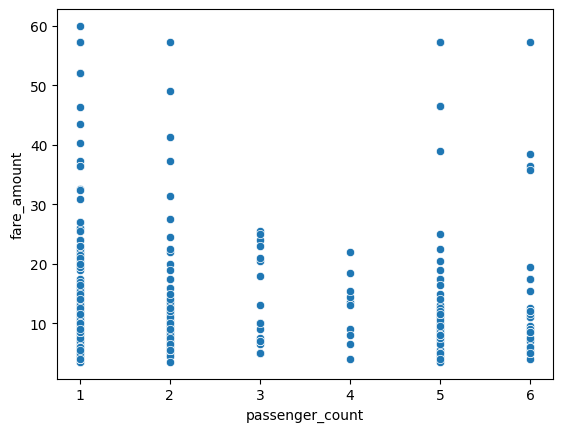

In [26]:
sns.scatterplot(x="passenger_count", y="fare_amount", data=train_df)



<Axes: xlabel='Year', ylabel='fare_amount'>

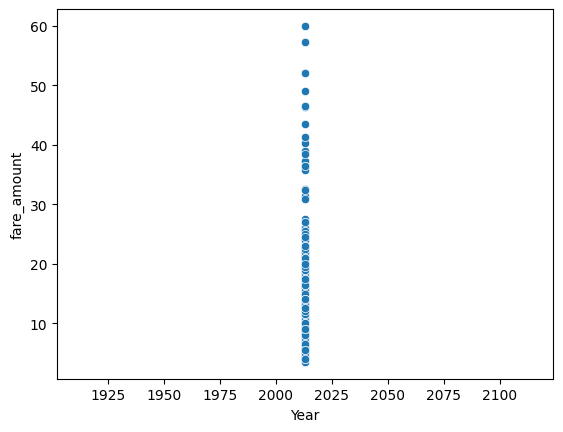

In [27]:
sns.scatterplot(x="Year", y="fare_amount", data=train_df)



<Axes: xlabel='Month', ylabel='fare_amount'>

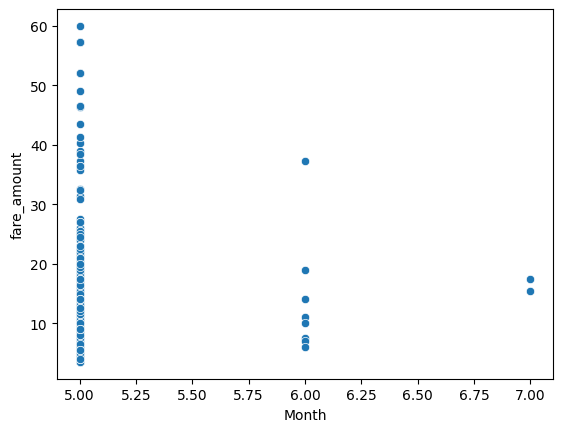

In [28]:
sns.scatterplot(x="Month", y="fare_amount", data=train_df)



<Axes: xlabel='Day', ylabel='fare_amount'>

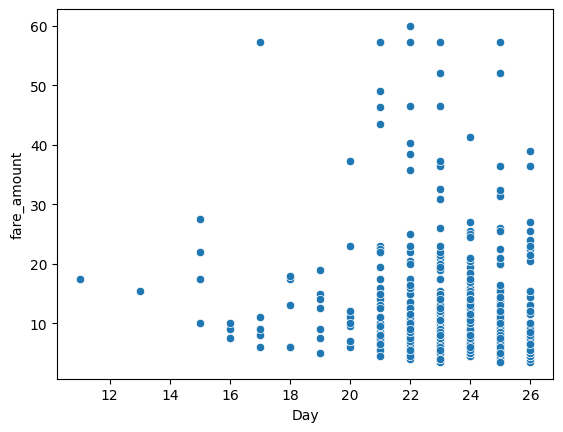

In [29]:
sns.scatterplot(x="Day", y="fare_amount", data=train_df)



<Axes: xlabel='Weekday', ylabel='fare_amount'>

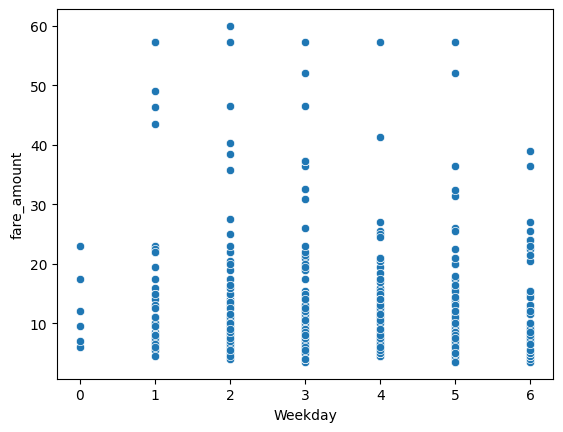

In [30]:
sns.scatterplot(x="Weekday", y="fare_amount", data=train_df)



<Axes: xlabel='Hour', ylabel='fare_amount'>

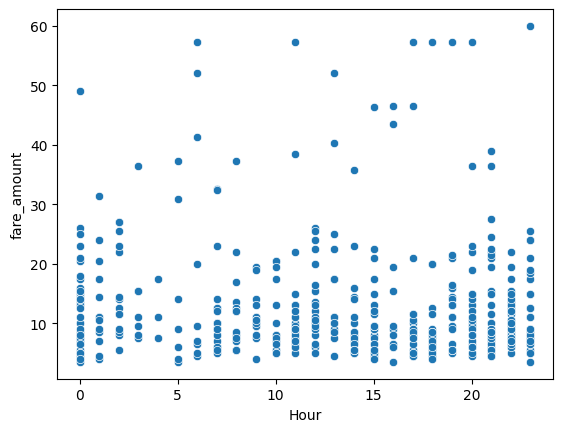

In [31]:
sns.scatterplot(x="Hour", y="fare_amount", data=train_df)



<Axes: xlabel='Distance', ylabel='fare_amount'>

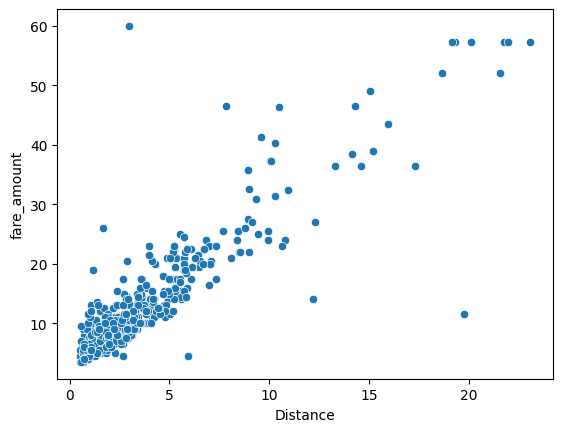

In [32]:
sns.scatterplot(x="Distance", y="fare_amount", data=train_df)



In [33]:
FEATURES = [
    "pickup_longitude",
    "pickup_latitude",
    "dropoff_longitude",
    "dropoff_latitude",
    "passenger_count",
    "Year",
    "Month",
    "Day",
    "Weekday",
    "Hour",
    "Distance",
]



In [34]:
train_df.replace([np.inf, -np.inf], np.nan, inplace=True)
test_df.replace([np.inf, -np.inf], np.nan, inplace=True)

before_train = len(train_df)
train_df = train_df.dropna(subset=FEATURES + ["fare_amount"]).reset_index(drop=True)
after_train = len(train_df)

train_feature_medians = train_df[FEATURES].median(numeric_only=True)

test_df[FEATURES] = test_df[FEATURES].fillna(train_feature_medians)
test_df[FEATURES] = test_df[FEATURES].fillna(0.0)

print(
    f"Dropped rows with NaN/Inf after feature engineering: train {before_train-after_train}, test 0 (imputed)"
)
print("Any NaNs left in test features:", test_df[FEATURES].isna().any().any())



Dropped rows with NaN/Inf after feature engineering: train 0, test 0 (imputed)
Any NaNs left in test features: False


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    train_df[FEATURES], train_df["fare_amount"], test_size=0.30, random_state=42
)



In [37]:
scaler = StandardScaler()
train_scalin = scaler.fit_transform(X_train)
val_scalin = scaler.transform(X_test)

test_df_ordered = test_df.reindex(test_keys.values)
assert test_df_ordered.shape[0] == len(
    test_keys
), "Reindexed test must match original test key count."
assert (
    test_df_ordered.index.astype(str).values == test_keys.values
).all(), "Test row order must exactly match test_keys before prediction."

test_scalin = scaler.transform(test_df_ordered[FEATURES])

y_train = y_train.to_numpy(dtype=np.float32)
y_test = y_test.to_numpy(dtype=np.float32)




In [38]:
def root_mean_squared_error(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_true)))




In [39]:
def build_and_compile_model(dim):
    model = tf.keras.Sequential(
        [
            layers.Dense(128, activation="relu", input_shape=(dim,)),
            layers.BatchNormalization(),
            layers.Dense(64, activation="relu"),
            layers.BatchNormalization(),
            layers.Dense(32, activation="relu"),
            layers.BatchNormalization(),
            layers.Dense(8, activation="relu"),
            layers.BatchNormalization(),
            layers.Dense(1),
        ]
    )

    model.compile(
        loss=tf.keras.losses.MeanSquaredError(),
        optimizer=tf.keras.optimizers.Adam(0.01),
        metrics=[root_mean_squared_error, "mae"],
    )
    return model




In [40]:
dnn_model = build_and_compile_model(dim=len(FEATURES))



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-17 13:12:00.640248: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1768655520.640731      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:06:00.0, compute capability: 8.6


In [41]:
ep_no = 10
Batch = 128

history = dnn_model.fit(
    train_scalin,
    y_train,
    validation_data=(val_scalin, y_test),
    batch_size=Batch,
    epochs=ep_no,
    verbose=1,
)

prediction = dnn_model.predict(test_scalin, batch_size=Batch, verbose=1).ravel()
prediction = np.clip(prediction, 0.0, None)

submission = pd.DataFrame(
    {"key": test_keys.values, "fare_amount": prediction.astype(np.float32)}
)
submission = submission[["key", "fare_amount"]]
submission.to_csv("taxi_fare_submission.csv", index=False)

print(submission.head())
print("Wrote taxi_fare_submission.csv with shape:", submission.shape)
print("fare_amount stats:", submission["fare_amount"].describe())
assert submission.shape[0] == len(
    test_keys
), "Submission row count must match test row count."
assert (
    submission["key"].astype(str).values == test_keys.values
).all(), "Submission keys must match test key order."

Epoch 1/10


I0000 00:00:1768655523.554142      70 service.cc:148] XLA service 0x7f89e4006890 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768655523.554188      70 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
2026-01-17 13:12:03.591775: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768655523.770438      70 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/3 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - loss: 296.3118 - mae: 13.2499 - root_mean_squared_error: 17.0999

I0000 00:00:1768655524.483014      70 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 724ms/step - loss: 263.6166 - mae: 12.7474 - root_mean_squared_error: 15.9618 - val_loss: 282.3222 - val_mae: 13.3376 - val_root_mean_squared_error: 14.2697
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 236.9151 - mae: 12.6285 - root_mean_squared_error: 15.9388 - val_loss: 272.6488 - val_mae: 13.2811 - val_root_mean_squared_error: 14.2753
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 225.6050 - mae: 12.5036 - root_mean_squared_error: 15.9073 - val_loss: 258.7517 - val_mae: 13.2150 - val_root_mean_squared_error: 14.3303
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 215.9762 - mae: 12.3667 - root_mean_squared_error: 15.8561 - val_loss: 245.5705 - val_mae: 13.1624 - val_root_mean_squared_error: 14.4275
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 207.1634 - mae: 12.2148 - root_mean_squared_error: 15.7953 - val_loss: 236.6962 - val_mae: 13.1922 - val_root_mean_squared_error: 14.5869
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━